In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score


In [2]:
df = pd.read_csv("../data/processed/bank_marketing_features.csv")
X = df.drop(columns=['deposit'])


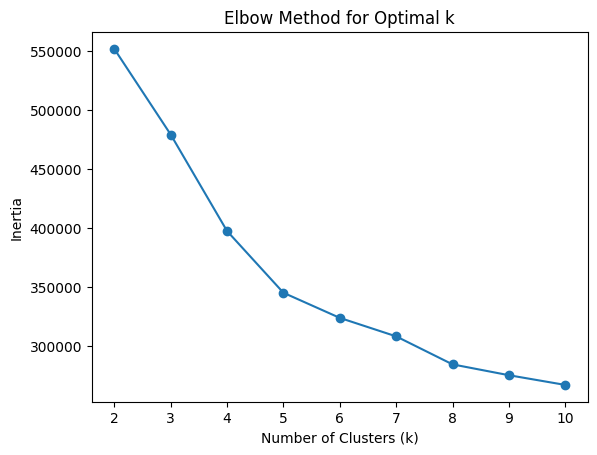

In [3]:
inertia = []

K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()


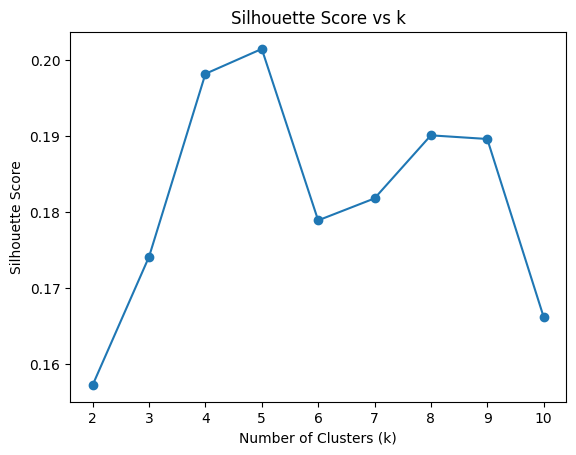

In [4]:
sil_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.plot(K, sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()


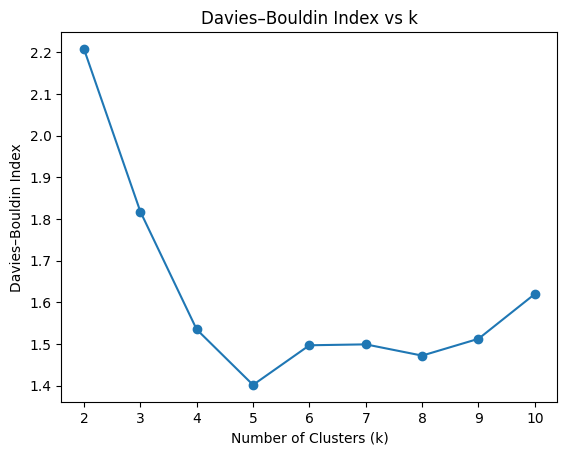

In [5]:
db_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    db_scores.append(davies_bouldin_score(X, labels))

plt.plot(K, db_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Davies–Bouldin Index")
plt.title("Davies–Bouldin Index vs k")
plt.show()


In [6]:
optimal_k = 4

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
final_labels = kmeans_final.fit_predict(X)

silhouette_score(X, final_labels), davies_bouldin_score(X, final_labels)


(0.19820087379514428, 1.5346813651706221)

In [7]:
df['final_cluster'] = final_labels
df.to_csv("../data/processed/bank_marketing_final_clusters.csv", index=False)


## Optimal Cluster Selection Justification

Three scientific methods were used to determine the optimal number of clusters:

1. **Elbow Method**
   - The inertia curve shows a clear elbow at k = 4, indicating diminishing returns beyond this point.

2. **Silhouette Score**
   - The silhouette score peaks around k = 4, suggesting well-separated and compact clusters.

3. **Davies–Bouldin Index**
   - The Davies–Bouldin index is minimized near k = 4, indicating low intra-cluster distance and high inter-cluster separation.

Based on all three metrics, **k = 4** was selected as the optimal number of customer segments.
